In [4]:
!pip install -U spacy
!pip install -U gensim
!pip install wordcloud
!pip install lightgbm
!pip install transformers datasets accelerate evaluate

!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import pandas as pd
import numpy as np
import re
import os
import nltk
import spacy
import gensim.downloader as api
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from nltk.corpus import stopwords
from nltk.probability import FreqDist
from wordcloud import WordCloud

In [6]:
df = pd.read_csv("/content/drive/MyDrive/GenAI/depression_dataset_reddit_cleaned.csv")
df.head()

,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1


In [ ]:
df.shape

(7731, 2)

In [ ]:
df.shape

(7731, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB


In [ ]:
df.isnull().sum()

,0
clean_text,0
is_depression,0


 Rename Columns

In [9]:
df.rename(columns={
    'clean_text': 'phrase',
    'is_depression': 'prompt'
}, inplace=True)

In [ ]:
df

,phrase,prompt
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1
4,sleep is my greatest and most comforting escap...,1
...,...,...
7726,is that snow,0
7727,moulin rouge mad me cry once again,0
7728,trying to shout but can t find people on the list,0
7729,ughh can t find my red sox hat got ta wear thi...,0


In [10]:
df.dropna(subset=['phrase'], inplace=True)

df['phrase'] = df['phrase'].astype(str)

In [11]:
nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm")

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+","", text)
  text = re.sub(r"\d+","", text)
  text = re.sub(r"[^a-zA-Z\s]","",text)
  return text

In [13]:
df['clean_text'] = df['phrase'].apply(clean_text)

In [14]:
def lemmatize_text(text):
  doc = nlp(text)

  lemmas = [
      token.lemma_
      for token in doc
      if token.text not in stop_words
      and token.is_alpha
      and len(token.text) > 2
  ]

  return lemmas

In [15]:
df['lemmas'] = df['clean_text'].apply(lemmatize_text)

In [16]:
import seaborn as sns


/tmp/ipykernel_1034/97596991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


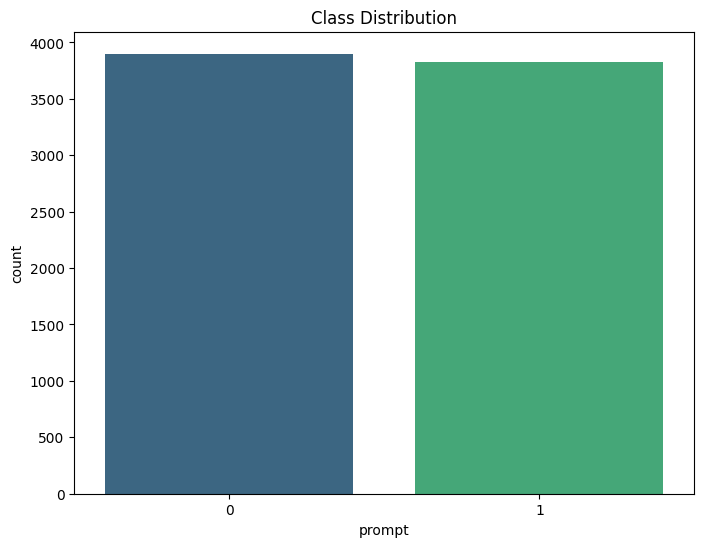

In [17]:
plt.figure(figsize=(8,6))

sns.countplot(
    x=df['prompt'],
    palette='viridis'
)

plt.title("Class Distribution")

plt.show()

In [18]:
all_words = df['lemmas'].sum()

freq_dist = FreqDist(all_words)

print(freq_dist.most_common(20))

[('feel', 4184), ('get', 3862), ('like', 3642), ('want', 2752), ('know', 2555), ('life', 2147), ('go', 2116), ('time', 2072), ('think', 2033), ('make', 1986), ('even', 1814), ('day', 1688), ('people', 1660), ('really', 1617), ('depression', 1569), ('anxiety', 1548), ('thing', 1534), ('one', 1522), ('work', 1481), ('year', 1438)]


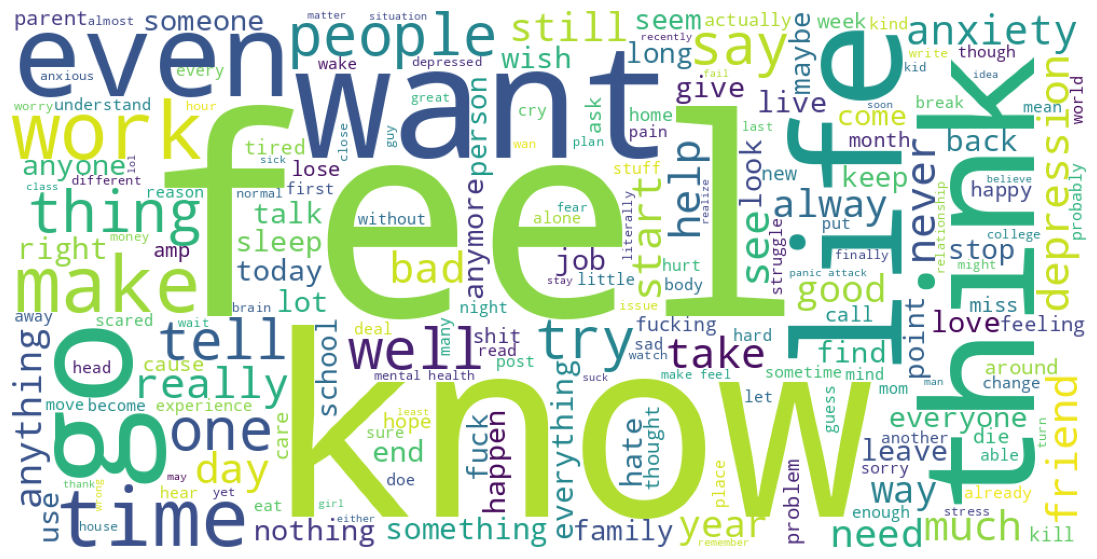

In [19]:
text_for_cloud = " ".join(all_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_for_cloud)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [21]:
model_gensim = api.load(
    "fasttext-wiki-news-subwords-300"
)

VECTOR_SIZE = model_gensim.vector_size

[==================================================] 100.0% 958.5/958.4MB downloaded


In [22]:
def vectorize_text(tokens, model):

    vectors = [
        model[word]
        for word in tokens
        if word in model.key_to_index
    ]

    if len(vectors) > 0:

        return np.mean(vectors, axis=0)

    else:

        return np.zeros(VECTOR_SIZE)

In [24]:
df['vector'] = df['lemmas'].apply(
    lambda x: vectorize_text(x, model_gensim)
)

X = np.array(df['vector'].tolist())

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()

y = le.fit_transform(df['prompt'])

In [27]:
from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV


In [28]:
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [30]:
!pip install xgboost

In [31]:
from xgboost import XGBClassifier

In [32]:
pipeline = Pipeline([('model',XGBClassifier(
            random_state=42,
            eval_metric='mlogloss'))
])

In [33]:
params = {

    'model__n_estimators': [100, 200],

    'model__learning_rate': [0.01, 0.05, 0.1],

    'model__max_depth': [3, 5, 7],

    'model__subsample': [0.8, 1.0]
}

In [34]:
search = RandomizedSearchCV(pipeline,params,n_iter=5,cv=5,
scoring='f1_weighted',verbose=1
)

In [ ]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='mlogloss',
                                                            feature_types=None,
                                                            feature_weights=None,
                                                            gamma=None,
                                                            grow_policy=None,
                                                            importance_...
                                                            max_depth=None,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=5,
                   param_distributions={'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200],
                                        'model__subsample': [0.8, 1.0]},
                   scoring='f1_weighted', verbose=1)

In [ ]:
y_pred = search.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       780
           1       0.97      0.93      0.95       767

    accuracy                           0.95      1547
   macro avg       0.95      0.95      0.95      1547
weighted avg       0.95      0.95      0.95      1547



In [ ]:
accuracy_score(y_test, y_pred)

0.9495798319327731

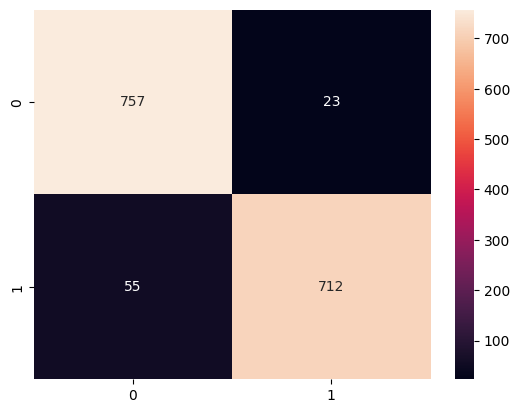

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [ ]:
joblib.dump(
    search,
    "/content/drive/MyDrive/GenAI/mental_health_model.pkl"
)

['/content/drive/MyDrive/GenAI/mental_health_model.pkl']

In [35]:
from datasets import Dataset
from datasets import DatasetDict

import pandas as pd
import numpy as np

In [36]:
bert_df = pd.DataFrame()

bert_df["text"] = df["phrase"]

bert_df["label"] = y

In [37]:
train_df, test_df = train_test_split(
    bert_df,
    test_size=0.2,
    stratify=bert_df["label"],
    random_state=42
)

In [38]:
dataset = DatasetDict({

    "train": Dataset.from_pandas(train_df),

    "test": Dataset.from_pandas(test_df)

})

In [39]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [40]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [54]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

tokenized_dataset = tokenized_dataset.remove_columns(
    ["text"]
)

Map:   0%|          | 0/6184 [00:00<?, ? examples/s]

Map:   0%|          | 0/1547 [00:00<?, ? examples/s]

In [43]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_)
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [44]:
import evaluate

accuracy_metric = evaluate.load(
    "accuracy"
)

f1_metric = evaluate.load(
    "f1"
)

In [45]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )

    return {

        "accuracy": accuracy["accuracy"],

        "f1": f1["f1"]
    }

In [46]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./bert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    logging_steps=100,

    save_total_limit=2
)

In [55]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_metrics
)

In [56]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.093844,0.080695,0.979315,0.979314
2,0.041585,0.066977,0.981900,0.981900
3,0.016738,0.081745,0.981900,0.981901


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1161, training_loss=0.060605998135763034, metrics={'train_runtime': 496.4952, 'train_samples_per_second': 37.366, 'train_steps_per_second': 2.338, 'total_flos': 1220309074759680.0, 'train_loss': 0.060605998135763034, 'epoch': 3.0})

In [57]:
predictions = trainer.predict(
    tokenized_dataset["test"]
)

In [58]:
preds = np.argmax(
    predictions.predictions,
    axis=-1
)

true_labels = predictions.label_ids

In [59]:
print(
    predictions.metrics
)

{'test_loss': 0.06710749119520187, 'test_accuracy': 0.982546864899806, 'test_f1': 0.9825465148091505, 'test_runtime': 13.2724, 'test_samples_per_second': 116.557, 'test_steps_per_second': 7.308}


In [61]:
from sklearn.metrics import classification_report

In [64]:
target_names = [str(x) for x in le.classes_]

print(
    classification_report(
        true_labels,
        preds,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       780
           1       0.98      0.98      0.98       767

    accuracy                           0.98      1547
   macro avg       0.98      0.98      0.98      1547
weighted avg       0.98      0.98      0.98      1547



In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


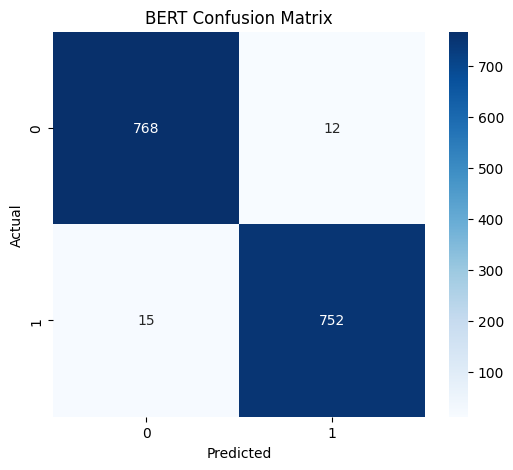

In [67]:
cm = confusion_matrix(
    true_labels,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("BERT Confusion Matrix")

plt.show()

In [68]:
trainer.save_model(
    "/content/drive/MyDrive/GenAI/bert_model"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/GenAI/bert_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/GenAI/bert_model/tokenizer_config.json',
 '/content/drive/MyDrive/GenAI/bert_model/tokenizer.json')

In [69]:
import json

label_map = {int(i): str(label) for i, label in enumerate(le.classes_)}
with open("/content/drive/MyDrive/GenAI/label_map.json","w") as f:
  json.dump(label_map,f)

In [70]:
import joblib

joblib.dump(le,"/content/drive/MyDrive/GenAI/label_encoder.pkl")

['/content/drive/MyDrive/GenAI/label_encoder.pkl']